## EDA and Data Cleaning

### Import Python Libraries and set properties for the notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from scipy.stats import chi2_contingency

In [2]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### Import data from the raw file

In [3]:
filepath = '../data/interim/neiss_interim_data.parquet'
data_interim = pd.read_parquet(filepath)

In [4]:
# Deep copy to preserve original data
data = data_interim.copy()

In [5]:
data.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight',
       'True_Age'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 27 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                int64         
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          int64         
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       
 

### 1. Feature Engineering 

#### 1.1 Add Hospitalization Feature

To develop statistically sound predictive models to reliably identify factors associated with hospitalization of product-related injuries; we need to create a target variable for Hospitalized (Yes/No) for each injury reported based on the disposition code.

In [7]:
# B. Define Target Variable (Hospitalization)
# Disposition Codes:
# 1=Released, 2=Transferred, 4=Hospitalized, 5=Held for Obs, 6=Left, 8=Fatality
# We group 2, 4, 5, and 8 as "Severe/Hospitalized"
disposition_codes = [2, 4, 5, 8]
data['Hospitalized'] = data['Disposition'].apply(lambda x: 1 if x in disposition_codes else 0)

In [8]:
Hospitalized_df = data.Hospitalized.value_counts(normalize=True).reset_index()
Hospitalized_df.columns = ['Hospitalized', 'Percentage']
print(Hospitalized_df)

   Hospitalized  Percentage
0             0        0.91
1             1        0.09


Data is unbalanced and we need to use any of the below techniques to balance the dataset.
1. Use the "class weight" parameter 
2. Use SMOTE (Oversampling) method 
3. Under Sampling - use all of the hospitalized data and take equal number of not_hospitalized data randomly. Could cause uncertain results.

#### 1.2 Add True Alcohol Flag

In [9]:
data.Alcohol.value_counts()

Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64

In [10]:
# Create a list of keywords (standard NEISS abbreviations)
alcohol_keywords = [
    # Medical & Formal
    'ALCOHOL', 'ETOH', 'INTOXICATED', 'INEBRIATED', 'DRUNK', 
    'SOBER', # Often appears as "Not Sober" or "Sobering up"
    'BAC ',  # Blood Alcohol Content (Need the space to avoid 'BACK')
    
    # Beverages
    'BEER', 'WINE', 'LIQUOR', 'VODKA', 'WHISKEY', 'WHISKY', 
    'TEQUILA', 'RUM', 'GIN', 'BRANDY', 'CHAMPAGNE', 'MOONSHINE',
    
    # Actions/Context
    'DRINKING', 'PARTY', 'BAR', 'PUB', 'CLUB', 'TAVERN',
    'HAPPY HOUR', 'KEG'
]

# Create a new column that searches the Narrative for these words
# Returns True if found, False if not
data['Alcohol_byNarrative'] = data['Narrative_1'].str.contains('|'.join(alcohol_keywords), case=False, na=False)
data['Alcohol_byNarrative'] = data['Alcohol_byNarrative'].astype(float)

# Check how many you found
#data['True_Alcohol_Flag'] = data['Alcohol_bool'] | data['Alcohol_Text_Flag']
print(data['Alcohol_byNarrative'].value_counts())
print(data['Alcohol'].value_counts())


Alcohol_byNarrative
0.00    6849504
1.00     466228
Name: count, dtype: int64
Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64


In [11]:
target_cols = ['Alcohol', 'Alcohol_byNarrative']
data['True_Alcohol'] = 0
mask_3 = data[target_cols].eq(3.0).any(axis=1)
data.loc[mask_3, 'True_Alcohol'] = 2
mask_1 = data[target_cols].eq(1).any(axis=1)
data.loc[mask_1, 'True_Alcohol'] = 1
print(data['Alcohol_byNarrative'].value_counts())
print(data['Alcohol'].value_counts())
print(data['True_Alcohol'].value_counts())


Alcohol_byNarrative
0.00    6849504
1.00     466228
Name: count, dtype: int64
Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64
True_Alcohol
2    4961221
0    1887004
1     467507
Name: count, dtype: int64


In [12]:
data.drop(columns=['Alcohol_byNarrative'], inplace=True)

#### 1.3 Add True Drug Flag

In [13]:
# 1. Define keywords for common substances & slang
drug_keywords = [
    # General Terms
    'DRUG', 'OVERDOSE', 'MEDICATION', 'PILL', 'TABLET', 'CAPSULE', 
    'INGEST', 'SUBSTANCE', 'NARCOTIC', 'OPIOID', 'OPIGTE', # Common typo
    
    # Street / Illegal
    'COCAINE', 'HEROIN', 'METHAMPHETAMINE', 'MARIJUANA', 'CANNABIS', 
    'FENTANYL', 'ECSTASY', 'MDMA', ' LSD ', ' PCP ', 'HASHISH',
    
    # Prescription / OTC (Brand & Generic)
    'XANAX', 'VALIUM', 'PERCOCET', 'VICODIN', 'OXYCODONE', 'OXYCONTIN',
    'ADDERALL', 'RITALIN', 'TYLENOL', 'ASPIRIN', 'IBUPROFEN', 'ADVIL',
    'MOTRIN', 'BENADRYL', 'INSULIN', 'VITAMIN', 'MORPHINE', 'CODEINE'
]
# 2. Create the Search Pattern (joins them with OR logic: "DRUG|OVERDOSE|...")
pattern = '|'.join(drug_keywords)
# 3. Create a True/False column based on the text
data['Drug_byNarrative'] = data['Narrative_1'].str.contains(pattern, case=False, na=False)
data['Drug_byNarrative'] = data['Drug_byNarrative'].astype(float)

# Check how many you found
print(data['Drug_byNarrative'].value_counts())
print(data['Drug'].value_counts())


Drug_byNarrative
0.00    7165429
1.00     150303
Name: count, dtype: int64
Drug
3.00    5283928
0.00    1986756
1.00      45048
Name: count, dtype: int64


In [14]:
target_cols = ['Drug', 'Drug_byNarrative']
data['True_Drug'] = 0
mask_3 = data[target_cols].eq(3.0).any(axis=1)
data.loc[mask_3, 'True_Drug'] = 2
mask_1 = data[target_cols].eq(1).any(axis=1)
data.loc[mask_1, 'True_Drug'] = 1
print(data['Drug_byNarrative'].value_counts())
print(data['Drug'].value_counts())
print(data['True_Drug'].value_counts())

Drug_byNarrative
0.00    7165429
1.00     150303
Name: count, dtype: int64
Drug
3.00    5283928
0.00    1986756
1.00      45048
Name: count, dtype: int64
True_Drug
2    5190144
0    1952580
1     173008
Name: count, dtype: int64


In [15]:
data.drop(columns=['Drug_byNarrative'], inplace=True)

### 3. Understanding the relationship of the Target Variable with the Predictors

In [16]:
data.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight',
       'True_Age', 'Hospitalized', 'True_Alcohol', 'True_Drug'],
      dtype='str')

#### 3.1 Understand the relationship between Categorical Features and the Target Variable

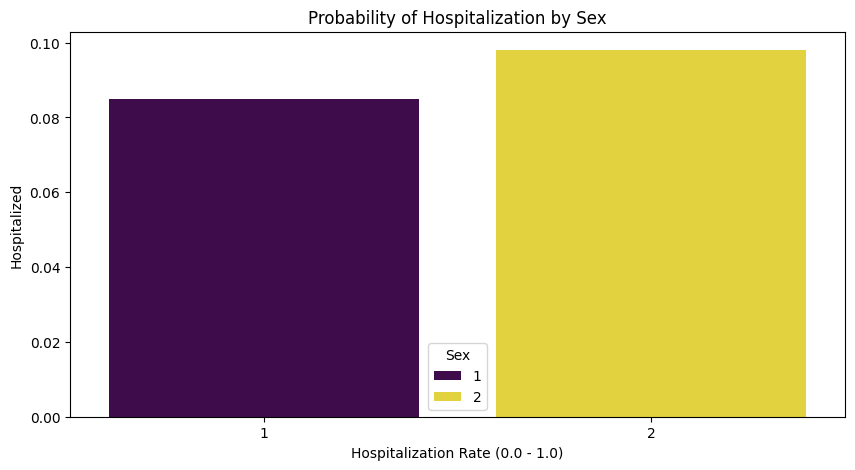

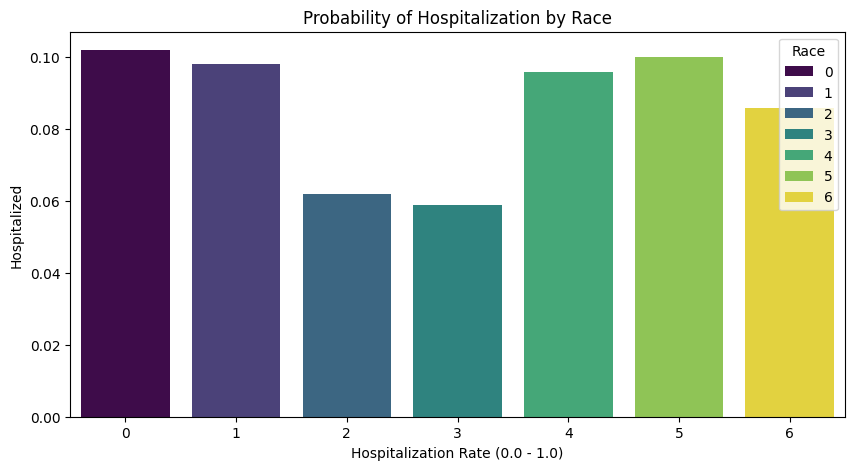

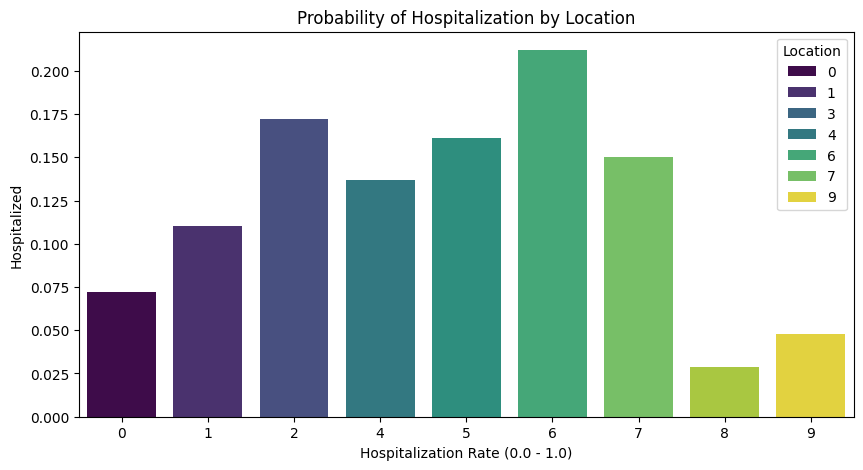

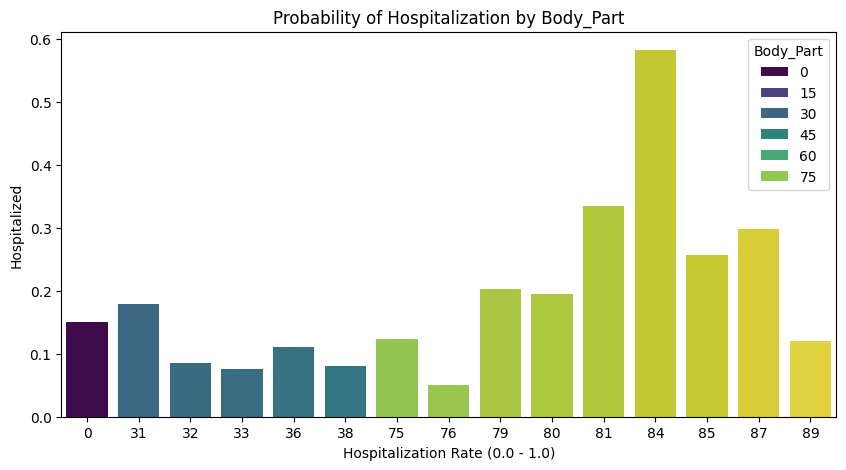

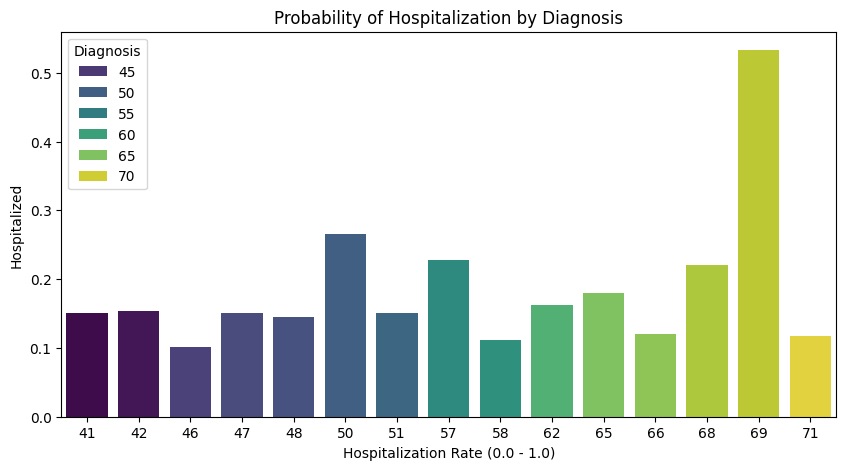

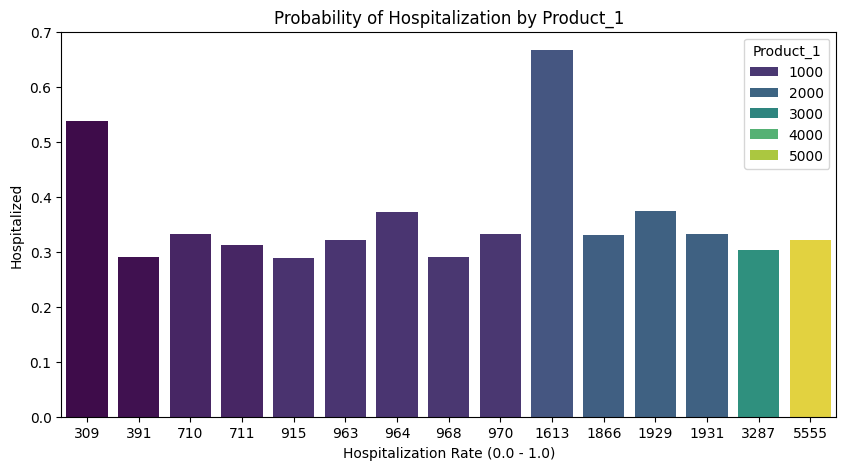

In [17]:
# Define categorical variables to analyze
categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1']

# Loop through and plot the "Risk"
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Calculate the mean of 'Target_Hospitalized' (which equals the % hospitalized)
    risk_df = data.groupby(col)['Hospitalized'].mean().round(3).reset_index().sort_values('Hospitalized', ascending=False)
    
    # Plot top 15 categories for readability
    sns.barplot(y='Hospitalized', x=col, data=risk_df.head(15), dodge=False, palette='viridis',hue=col)
    
    plt.title(f'Probability of Hospitalization by {col}')
    ##plt.xticks(rotation=90)
    plt.xlabel('Hospitalization Rate (0.0 - 1.0)')
    plt.show()

In [18]:
data.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight',
       'True_Age', 'Hospitalized', 'True_Alcohol', 'True_Drug'],
      dtype='str')

In [19]:
# Define categorical variables to analyze
categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1','Other_Race','Hispanic','Fire_Involvement','True_Alcohol','True_Drug','Stratum']

# Loop through and plot the "Risk"
for col in categorical_cols:
    # Example: Check if Sex predicts Hospitalization
    contingency_table = pd.crosstab(data[col], data['Hospitalized'])
    #print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        print(f'{col} is a significant predictor.')
    else:
        print(f'{col} is likely noise.')

Sex is a significant predictor.
Race is a significant predictor.
Location is a significant predictor.
Body_Part is a significant predictor.
Diagnosis is a significant predictor.
Product_1 is a significant predictor.
Other_Race is a significant predictor.
Hispanic is a significant predictor.
Fire_Involvement is a significant predictor.
True_Alcohol is a significant predictor.
True_Drug is a significant predictor.
Stratum is a significant predictor.


In [23]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Your list of "Significant" variables
predictors = [
    'Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis', 
    'Product_1', 'Fire_Involvement', 'True_Alcohol', 
    'True_Drug', 'Stratum'
]

# Calculate and Rank
results = []
for col in predictors:
    score = cramers_v(data[col], data['Hospitalized'])
    results.append({'Feature': col, 'Cramers_V': score})

# Show the leaderboard
rank_df = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False)
rank_df

,Feature,Cramers_V
4,Diagnosis,0.28
3,Body_Part,0.26
5,Product_1,0.23
2,Location,0.11
8,True_Drug,0.09
7,True_Alcohol,0.08
9,Stratum,0.07
1,Race,0.06
6,Fire_Involvement,0.05
0,Sex,0.02


#### 3.1 Understand the relationship between Numerical Features and the Target Variable

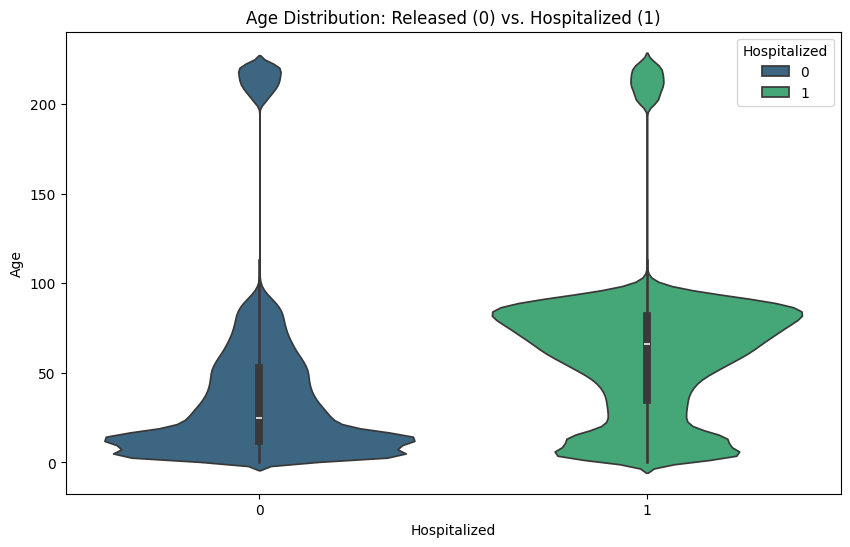

In [20]:
plt.figure(figsize=(10, 6))

# A Violin plot shows the shape of the data better than a box plot here
sns.violinplot(x='Hospitalized', y='Age', data=data, hue='Hospitalized', palette='viridis')

plt.title('Age Distribution: Released (0) vs. Hospitalized (1)')
plt.show()

### 4. Perfrom Encoding for Numeric Fields 

### 5. Save the data to the interim folder for future use

In [21]:
#data.to_csv('../data/processed/neiss_processed_data.csv', index=False)
data.to_parquet('../data/processed/neiss_processed_data.parquet')